# Project Name - Credit Card Default Prediction using Machine Learning
- by Kartik Mohan

In [1]:
import pandas as pd

df = pd.read_excel("/content/drive/MyDrive/Bank_Credit_card_ML_Project/default of credit card clients.xls")
df.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [4]:
df.shape

(30001, 25)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30001 entries, 0 to 30000
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  30001 non-null  object
 1   X1          30001 non-null  object
 2   X2          30001 non-null  object
 3   X3          30001 non-null  object
 4   X4          30001 non-null  object
 5   X5          30001 non-null  object
 6   X6          30001 non-null  object
 7   X7          30001 non-null  object
 8   X8          30001 non-null  object
 9   X9          30001 non-null  object
 10  X10         30001 non-null  object
 11  X11         30001 non-null  object
 12  X12         30001 non-null  object
 13  X13         30001 non-null  object
 14  X14         30001 non-null  object
 15  X15         30001 non-null  object
 16  X16         30001 non-null  object
 17  X17         30001 non-null  object
 18  X18         30001 non-null  object
 19  X19         30001 non-null  object
 20  X20   

In [6]:
df = df.apply(pd.to_numeric, errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30001 entries, 0 to 30000
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  30000 non-null  float64
 1   X1          30000 non-null  float64
 2   X2          30000 non-null  float64
 3   X3          30000 non-null  float64
 4   X4          30000 non-null  float64
 5   X5          30000 non-null  float64
 6   X6          30000 non-null  float64
 7   X7          30000 non-null  float64
 8   X8          30000 non-null  float64
 9   X9          30000 non-null  float64
 10  X10         30000 non-null  float64
 11  X11         30000 non-null  float64
 12  X12         30000 non-null  float64
 13  X13         30000 non-null  float64
 14  X14         30000 non-null  float64
 15  X15         30000 non-null  float64
 16  X16         30000 non-null  float64
 17  X17         30000 non-null  float64
 18  X18         30000 non-null  float64
 19  X19         30000 non-nul

In [7]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [8]:
df['Y'].value_counts()

,count
Y,
0.0,23364
1.0,6636


In [9]:
(df['Y'].value_counts(normalize=True)) * 100

,proportion
Y,
0.0,77.88
1.0,22.12


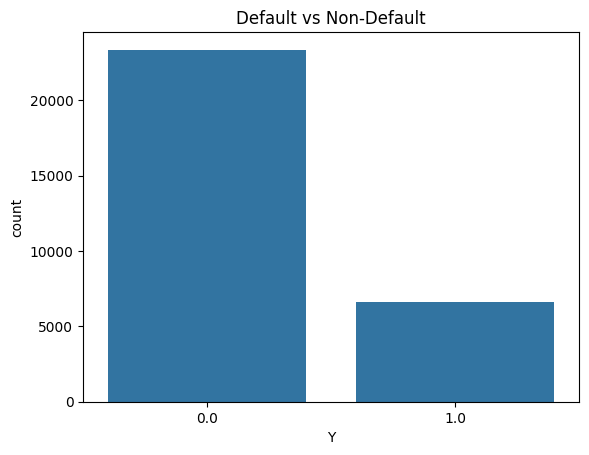

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Y', data=df)
plt.title("Default vs Non-Default")
plt.show()

- ~78% → No default
- ~22% → Default
- Dataset is IMBALANCED
- Hypothesis:
- H0 (Null): Default is random (no pattern)
- H1 (Alternative): Default depends on features
I will reject H0 using analysis

In [11]:
# Checking if AGE affects default
import scipy.stats as stats

# Separate groups
no_default = df[df['Y'] == 0]['X5']
default = df[df['Y'] == 1]['X5']

# t-test
t_stat, p_value = stats.ttest_ind(no_default, default)

print("P-value:", p_value)

P-value: 0.016136845890163835


- p-value = 0.016 (p-value < 0.05), So we REJECT H0 & Age DOES affect default
- I tested whether age affects default using a t-test. The p-value was 0.016, which is less than 0.05. So I rejected the null hypothesis and concluded that age has a significant effect on credit card default.

In [ ]:
# check another IMPORTANT feature

In [12]:
no_default = df[df['Y'] == 0]['X1']
default = df[df['Y'] == 1]['X1']

t_stat, p_value = stats.ttest_ind(no_default, default)

print("P-value:", p_value)

P-value: 1.3022439532597397e-157


- p-value = 1.30 × 10⁻¹⁵⁷ (extremely small) & Accepted H1
- I tested whether credit limit affects default. The p-value was extremely small, almost zero. So I strongly rejected the null hypothesis and concluded that credit limit has a significant impact on default prediction.

In [13]:
for col in ['X6', 'X7', 'X8', 'X9', 'X10', 'X11']:
    no_default = df[df['Y'] == 0][col]
    default = df[df['Y'] == 1][col]

    t_stat, p_value = stats.ttest_ind(no_default, default)

    print(f"{col} → P-value: {p_value}")

X6 → P-value: 0.0
X7 → P-value: 0.0
X8 → P-value: 0.0
X9 → P-value: 0.0
X10 → P-value: 1.1266079544980244e-279
X11 → P-value: 7.296740483279229e-234


- All p-values are: 0 or extremely close to 0
- Payment history has a very strong impact on default. All p-values are extremely small, so we reject the null hypothesis. This shows that past payment behavior is a key factor in predicting whether a customer will default.

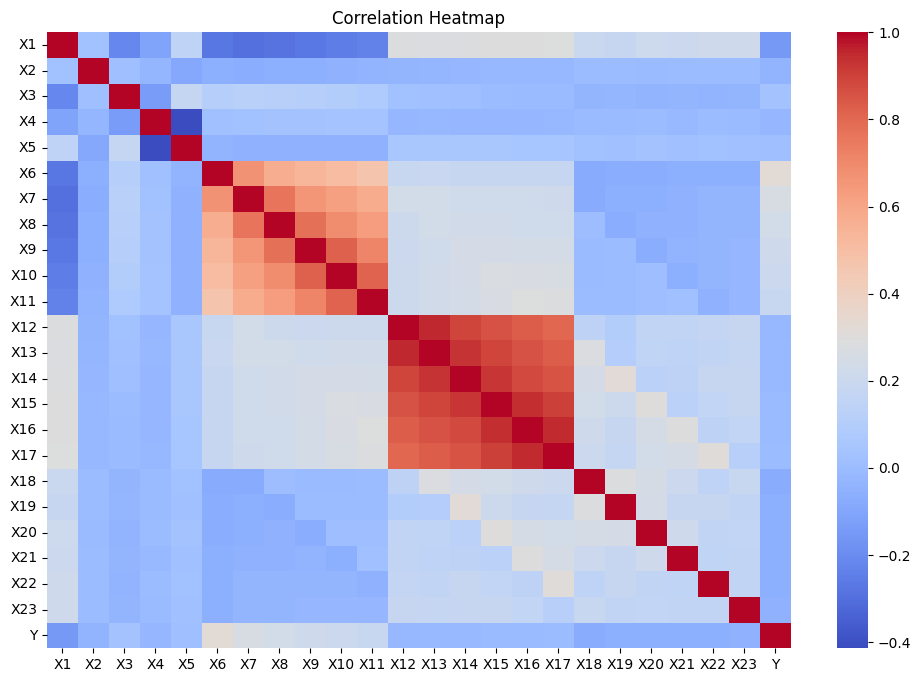

In [14]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

- Red color → strong positive relation
- Blue color → negative relation
- Light color → weak relation

- X6–X11 (Payment history) → strong relation

Moderate features:
- X1 (Credit limit)
- X12–X17 (Bill amounts)

Weak features:
- X2 (Gender)
- X3 (Education)
- X4 (Marriage)

Highly correlated features indicate strong predictive power, especially payment history which consistently shows high correlation with the target.

In [15]:
# Feature Selection
selected_features = ['X1','X5','X6','X7','X8','X9','X10','X11',
                     'X12','X13','X14','X15','X16','X17']

X = df[selected_features]
y = df['Y']

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())
y_train = y_train.fillna(y_train.median())
y_test = y_test.fillna(y_test.median())

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

- Before Data was not scaled -> model struggling to learn properly, I applied feature scaling using StandardScaler to normalize the data. This helps Logistic Regression converge faster and improves model performance.

In [27]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [28]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8098650224962506

Confusion Matrix:
 [[4563  110]
 [1031  297]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.82      0.98      0.89      4673
         1.0       0.73      0.22      0.34      1328

    accuracy                           0.81      6001
   macro avg       0.77      0.60      0.62      6001
weighted avg       0.80      0.81      0.77      6001



- Accuracy → overall performance
- Confusion Matrix → correct vs wrong predictions
- Precision / Recall / F1 → detailed performance

In [29]:

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.8116980503249458

Confusion Matrix:
 [[4380  293]
 [ 837  491]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.84      0.94      0.89      4673
         1.0       0.63      0.37      0.46      1328

    accuracy                           0.81      6001
   macro avg       0.73      0.65      0.68      6001
weighted avg       0.79      0.81      0.79      6001



- 4563 → Correctly predicted No Default
- 297 → Correctly predicted Default
- 1031 → Missed defaults (VERY IMPORTANT)
- 110 → Wrongly predicted default

 Model is bad at predicting defaults

 Model is missing many defaulters

- Out of all actual defaulters: It only catches 22%

In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 5, 'n_estimators': 100}


In [34]:
y_prob = rf.predict_proba(X_test)[:,1]

y_pred_custom = (y_prob > 0.3).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

         0.0       0.87      0.84      0.85      4673
         1.0       0.49      0.54      0.51      1328

    accuracy                           0.77      6001
   macro avg       0.68      0.69      0.68      6001
weighted avg       0.78      0.77      0.78      6001



- Model Catches 54% defaulters (earlier only 22%) Much better for real-world use & We care more about catching defaulters than overall accuracy.
- After handling class imbalance using class weights, the recall for defaulters improved significantly from 22% to 54%. Although accuracy slightly decreased, this trade-off is acceptable because identifying defaulters is more important in this problem.
- In credit risk problems, minimizing false negatives is critical, and this approach helped improve detection of risky customers.

In [38]:
# Lets test our Project

import numpy as np

# Example customer (you can change values later)
sample = np.array([[200000, 30, -1, -1, 0, 0, 0, 0,
                    5000, 4000, 3000, 2000, 1000, 500]])

# Apply same scaling
sample_scaled = scaler.transform(sample)

# Predict
prediction = rf.predict(sample_scaled)

print("Prediction:", prediction)
# ignore the warning

Prediction: [0.]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [37]:
sample_df = pd.DataFrame(sample, columns=X.columns)
sample_scaled = scaler.transform(sample_df)
prob = rf.predict_proba(sample_scaled)
print("Probability of Default:", prob[0][1])

Probability of Default: 0.12


- Only 12% chance of default,So customer is low risk
- The model predicted a 12% probability of default, which indicates that the customer is low risk and likely to repay the credit.

Bank can do:

- If probability > 0.6 -> Reject loan
- If probability < 0.3 -> Approve loan
- Else -> Manual review